In [1]:
print("Hello World!")

Hello World!


In [2]:
# TODO: spojiti data.txt i labels.txt u jedan data.csv (prepakovani podaci) i proveriti strukturu
# ocekujem da bude 4480 redova, 40 razlicitih subjekata, pa za svakog po 112 redova merenja, i za svakog subjekta po 28 merenja iz svake aktivnost
# odnosno, klase su balansirane
# ocekujem 535 kolona, od kojih su 533 atributi koji ucestvuju u klasifikaciji, prvi atribut je id subjekta koji ucestvuje u podeli i uzorkovanju podataka,
# poslednji atribut je ciljna klasa (1-neutral, 2-emontional, 3-mental, 4-physical)
# nema nedostajucih vrednosti, svi atributi su realne vrednosti, i ciljna klasa koja je kategorickog tipa je vec kodirana
# atributi za EDA signale iz ruke i sake imaju ista imena (jesu isti, ali za razlicite delove tela), pa treba dodati prefikse kako bi se znalo o kojem tacno signalu je rec
# prvo idu 104 EDA signala vezanih za ruku, pa potom 104 EDA signala vezana za saku

csv_filename = "data/data.csv"

# granice blokova atributa (indeksi kolona, 0-bazirani):
# 0 - subject_id, 1..174 - ECG, 175..325 - TEB, 326..429 - EDA ruka, 430..533 - EDA saka, 534 - target
EDA_ARM_START = 326
EDA_HAND_START = 430

def transform_to_csv(labels: str = "", data: str = ""):
    with open(labels, "r") as f_labels:
        with open(data, "r") as f_data:
            labels = f_labels.readlines()
            labels = list(map(str.strip, labels))
            data = f_data.readlines()
            data = list(map(str.strip, data))
            labels = labels[:-1]
            # zamenjujemo naziv poslednjeg ciljnog atributa u 'target'
            labels.append("target")
            # zamenjujemo naziv prvog atributa u subject_id
            labels[0] = "subject_id"

            # EDA podaci za ruku i saku imaju ista imena, pa ih transformisemo dodavanjem dela tela na kojem su mereni
            # opsezi se ne smeju preklapati, inace bi kolona na granici dobila oba prefiksa (npr. EDA_Hand_Arm_...)
            for i in range(EDA_ARM_START, EDA_HAND_START):
                prefix, sufix = labels[i].split("_", maxsplit=1)
                labels[i] = prefix + "_Arm_" + sufix
            for i in range(EDA_HAND_START, len(labels) - 1):
                prefix, sufix = labels[i].split("_", maxsplit=1)
                labels[i] = prefix + "_Hand_" + sufix

            print(labels[:EDA_ARM_START])
            print(labels[EDA_ARM_START:EDA_HAND_START])
            print(labels[EDA_HAND_START:-1])
            csv_data = data
            csv_data.insert(0, ",".join(labels))
            with open(csv_filename, "w") as f_csv:
                f_csv.writelines(f"{item}\n" for item in csv_data)

transform_to_csv(labels="data/labels.txt", data="data/data.txt")

['subject_id', 'ECG_original_mean', 'ECG_original_std', 'ECG_original_trimmean25', 'ECG_original_median', 'ECG_original_skewness', 'ECG_original_kurtosis', 'ECG_original_max', 'ECG_original_min', 'ECG_original_prctile25', 'ECG_original_prctile75', 'ECG_original_geomean(abs)', 'ECG_original_harmmean', 'ECG_original_mad', 'ECG_original_baseline', 'ECG_RR_window_mean', 'ECG_RR_window_std', 'ECG_RR_window_trimmean25', 'ECG_RR_window_median', 'ECG_RR_window_skewness', 'ECG_RR_window_kurtosis', 'ECG_RR_window_max', 'ECG_RR_window_min', 'ECG_RR_window_prctile25', 'ECG_RR_window_prctile75', 'ECG_RR_window_geomean(abs)', 'ECG_RR_window_harmmean', 'ECG_RR_window_mad', 'ECG_RR_window_baseline', 'ECG_amplitude_RR_mean', 'ECG_amplitude_RR_std', 'ECG_amplitude_RR_trimmean25', 'ECG_amplitude_RR_median', 'ECG_amplitude_RR_skewness', 'ECG_amplitude_RR_kurtosis', 'ECG_amplitude_RR_max', 'ECG_amplitude_RR_min', 'ECG_amplitude_RR_prctile25', 'ECG_amplitude_RR_prctile75', 'ECG_amplitude_RR_geomean(abs)', '

In [3]:
import pandas as pd
import numpy as np

# provera da ispravno pravimo data.csv fajl od polaznih fajlova koji predstavljaju dataset kako bi olaksali upotrebu i manipulaciju dataset-om
df = pd.read_csv(csv_filename)
print(df.head())

print("Provera broja NaN/null vrednosti:")
print(df.isna().sum().sum())

print("Provera broja inf vrednosti za numericke atribute:")
print(np.isinf(df.select_dtypes(include=np.number)).sum().sum())

print("Provera broja redova i kolona: ")
print(df.shape)

print("Provera broja subjekata i balansiranosti podataka po subjektu: ")
print(df[["subject_id", "target"]].value_counts())

print("Provera balansiranosti klasa: ")
print(df["target"].value_counts())

print("Provera broja atributa po vrsti merenja:")
print(f"ECG: {df.columns.str.startswith("ECG").sum()}")
print(f"TIB: {df.columns.str.startswith("IT").sum()}")
print(f"EDA arm: {df.columns.str.startswith("EDA_Arm").sum()}")
print(f"EDA hand: {df.columns.str.startswith("EDA_Hand").sum()}")

   subject_id  ECG_original_mean  ECG_original_std  ECG_original_trimmean25  \
0           1          -0.004125          0.254095                 0.001426   
1           1           0.031029          0.193761                 0.012918   
2           1           0.015678          0.182336                -0.003028   
3           1           0.014525          0.176636                -0.006161   
4           1           0.010349          0.179248                -0.008526   

   ECG_original_median  ECG_original_skewness  ECG_original_kurtosis  \
0             -0.01037              -0.538509                5.95534   
1             -0.00237               0.781415                5.18794   
2             -0.02337               0.881194                5.66530   
3             -0.02737               1.024900                6.10968   
4             -0.02737               0.935697                5.83902   

   ECG_original_max  ECG_original_min  ECG_original_prctile25  ...  \
0           1.04063   

In [4]:
# Skup podataka delimo tako da se svi redovi jednog ispitanika (subject_id) nalaze ili u trening ili u test skupu
# To radimo zato sto svaki ispitanik je zivi organizam koji moze imati specificno reagovanje na odredjene aktivnosti (prilikom neke aktivnosti se vise znoji, ili
# ima pojacano disanje, ili ima manje otkucaje srca), pa kako bi izbegli situaciju da se odredjena aktivnost klasifikuje tako sto se prepozna da je ispitanik sa
# odredjenim subject_id-em imao bas tu aktivnost umesto da se aktivnost prepozna na osnovu vrednosti izmerenih atributa (model je prikupio sum vezan za ispitanika
# tokom treniranja), skup delimo tako da se u test podacima nalaze ispitanici koji josuvek nisu vidjeni, umesto klasicne stratifikovane podele. Takodje dodatna
# stratifikovana podela nije potrebna, jer su podaci balansirani na nacin da svaki ispitanik ima 28 redova (merenja) svake od 4 aktivnosti, pa ce podaci u trening
# i test skupu nakon podele biti balansirani

from sklearn.model_selection import GroupShuffleSplit

RANDOM_STATE = 42
TEST_SIZE = 0.2

X = df.drop(columns=["subject_id", "target"])
y = df["target"]
groups = df["subject_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

print("Dimenzije trening skupa: ", X_train.shape, y_train.shape)
print("Dimenzije test skupa: ", X_test.shape, y_test.shape)

print("Provera da se subjekti ne preklapaju izmedju trening i test skupa: ")
print("Broj zajednickih subjekata: ", len(set(groups_train) & set(groups_test)))
print("Broj subjekata u trening skupu: ", groups_train.nunique())
print("Broj subjekata u test skupu: ", groups_test.nunique())
print("Subjekti u test skupu: ", sorted(set(groups_test)))

print("Provera da su svi redovi svakog subjekta ostali na istoj strani podele: ")
print(all(groups_train.value_counts() == 112) and all(groups_test.value_counts() == 112))

print("Provera balansiranosti klasa u trening skupu: ")
print(y_train.value_counts(normalize=True).sort_index())
print("Provera balansiranosti klasa u test skupu: ")
print(y_test.value_counts(normalize=True).sort_index())

Dimenzije trening skupa:  (3584, 533) (3584,)
Dimenzije test skupa:  (896, 533) (896,)
Provera da se subjekti ne preklapaju izmedju trening i test skupa: 
Broj zajednickih subjekata:  0
Broj subjekata u trening skupu:  32
Broj subjekata u test skupu:  8
Subjekti u test skupu:  [5, 13, 16, 17, 20, 27, 28, 38]
Provera da su svi redovi svakog subjekta ostali na istoj strani podele: 
True
Provera balansiranosti klasa u trening skupu: 
target
1    0.25
2    0.25
3    0.25
4    0.25
Name: proportion, dtype: float64
Provera balansiranosti klasa u test skupu: 
target
1    0.25
2    0.25
3    0.25
4    0.25
Name: proportion, dtype: float64


In [5]:
# Redukcija atributa preko kombinacija vise filter statistika.
# Prvo odbacujemo atribute koji imaju varijansu blisku nuli, zato sto to znaci da gotovo svi redovi imaju konstantnu vrednost, i atribut onda nikako ne ucestvuje
# u razdvajanju redova u klase
# Onda racunamo mutual information atributa, kako bi kasnije izdvajali atribute po vaznosti. Mutual information (uzajamna informisanost) meri koliko saznajemo o
# ciljnoj klasi ako znam vrednost atributa, kao razlika entropija, mera iznenadjenja, neizvesnosti labele H(Y) i H(Y|X), mera iznenadjenja Y ako znamo X (nas
# atribut). Sto je ova razlika veca, to su nas atribut informativniji za predikciju klase. Mana ove metrike je ta sto ona gleda koliko svaki atribut izolovano
# predvidja klasu, ali se moze odbaciti atribut koji jako dobro predvidja klasu u kombinaciji sa drugim atributima, pa to treba imati u vidu.
# Zatim postoji grupa atributa koji opisuju istu stvar (ECG_hrv_mean, ECG_hrv_median i ECG_trimmean25 su sve mere centra iste raspodele), odnosno postoji
# redudansa medju atributima. Ali su zato i redudantni atributi medjusobno jako korelisani, pa zbog toga cemo grupisati atribute u klastere na osnovu korelacije,
# i zatim iz svakog klastera uzeti predstavnika koji ima najveci mutual information.
# Na kraju cemo od preostalih atributa uzeti top 15 po mutual information
# TODO: U nastavku cemo analizirati raspodele ovih atributa preko histograma i boxplot-ova

# Redukcija dimenzionalnosti u 4 koraka, iskljucivo nad trening skupom (test skup se na kraju samo suzava na izabrane kolone,
# jer bi racunanje varijanse, uzajamne informacije ili korelacije nad celim skupom znacilo curenje informacija iz test skupa).
# Namerno ne koristimo PCA i slicne metode - one prave nove atribute kao linearne kombinacije polaznih, pa se gubi fizicko znacenje signala.
# Ovde je cilj da krajnji skup atributa bude pravi podskup polaznih atributa, kako bi rezultat ostao interpretabilan
# (moze da se kaze tacno koje merenje sa kog senzora razdvaja aktivnosti).

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.feature_selection import mutual_info_classif

# iako atributi mogu i verovatno jesu na razlicitim skalama (merenja u razlicitim redovima velicine) zbog cega provera da li su gotovo konstante vrednosti svih
# redova preko apsolutne vrednosti za varijansu moze biti pogresna (ako su sve vrednosti malog reda velicine), ali ovoliko mali broj mozemo smatrati gotovo nula u
# bilo kom redu velicine
VARIANCE_THRESHOLD = 1e-12
CORR_THRESHOLD = 0.8  # granica preko koje smatramo da su dva atributa redundantna
TOP_K = 15

# --- Korak 1: izbacujemo atribute cija je varijansa bliska nuli ---
# takvi atributi su prakticno konstantni kroz sva merenja, pa ni ne mogu da razdvoje redove po klasama
variances = X_train.var()
low_variance_mask = variances.abs() < VARIANCE_THRESHOLD
X_train_step1 = X_train.loc[:, ~low_variance_mask]

print("Korak 1 - filtriranje po varijansi:")
print("Broj atributa pre filtriranja: ", X_train.shape[1])
print("Broj izbacenih atributa: ", int(low_variance_mask.sum()))
print("Izbaceni atributi: ", list(variances.index[low_variance_mask]))
print("Broj atributa posle filtriranja: ", X_train_step1.shape[1])

# --- Korak 2: uzajamna informacija (mutual information) izmedju svakog atributa i ciljne klase ---
# za razliku od korelacije sa ciljem, MI hvata i nelinearne veze, a ciljna klasa je kategoricka pa nam korelacija ovde ionako ne bi valjala
mi_scores = pd.Series(
    mutual_info_classif(X_train_step1, y_train, random_state=RANDOM_STATE),
    index=X_train_step1.columns,
)

print("Korak 2 - uzajamna informacija:")
print("Najboljih 10 atributa po MI: ")
print(mi_scores.sort_values(ascending=False).head(10))

# --- Korak 3: grupisemo redundantne atribute hijerarhijskim klasterovanjem po korelaciji ---
# veliki broj atributa opisuje istu stvar na malo drugaciji nacin (npr. ECG_hrv_mean, ECG_hrv_median i ECG_hrv_trimmean25 su sve mere centra iste raspodele),
# pa nose skoro istu informaciju i samo vestacki uvecavaju dimenziju.
# Koristimo Spearman-ovu korelaciju jer je otporna na ekstremne vrednosti (a ovde ima atributa reda 1e8) i hvata sve monotone, ne samo linearne veze.
# Rastojanje definisemo kao 1 - |korelacija|, pa jako korelisani atributi imaju malo rastojanje bez obzira na znak korelacije.
# Average linkage je prikladan za ovakvu matricu rastojanja, dok ward metod nije jer on zahteva euklidsko rastojanje.
corr_matrix = X_train_step1.corr(method="spearman").fillna(0.0)
abs_corr = corr_matrix.abs()
distance_matrix = 1.0 - abs_corr.to_numpy()
# numericka simetrizacija - squareform zahteva tacno simetricnu matricu sa nulama na dijagonali
distance_matrix = (distance_matrix + distance_matrix.T) / 2.0
np.fill_diagonal(distance_matrix, 0.0)
distance_matrix = np.clip(distance_matrix, 0.0, 1.0)

linkage_matrix = linkage(squareform(distance_matrix, checks=False), method="average")
clusters = pd.Series(
    fcluster(linkage_matrix, t=1.0 - CORR_THRESHOLD, criterion="distance"),
    index=X_train_step1.columns,
)

# iz svakog klastera uzimamo jednog predstavnika - atribut sa najvecom uzajamnom informacijom
representatives = list(mi_scores.groupby(clusters).idxmax())

print("Korak 3 - klasterovanje korelisanih atributa:")
print("Broj klastera (odnosno broj preostalih atributa): ", clusters.nunique())
print("Broj atributa koji su bili u klasteru sa bar jos jednim atributom: ", int((clusters.map(clusters.value_counts()) > 1).sum()))
print("Najveci klasteri (grupe redundantnih atributa) i njihovi predstavnici: ")
for cluster_id, size in clusters.value_counts().head(3).items():
    members = list(clusters.index[clusters == cluster_id])
    print(f"  klaster {cluster_id}, velicina {size}, predstavnik: {mi_scores.loc[members].idxmax()}")
    print(f"    clanovi: {members[:5]}{' ...' if len(members) > 5 else ''}")

# --- Korak 4: od predstavnika klastera uzimamo TOP_K najboljih po uzajamnoj informaciji ---
# Vazno: klasterovanje samo po sebi NE garantuje da predstavnici razlicitih klastera nisu medjusobno redundantni.
# Average linkage spaja klastere po prosecnom rastojanju, pa pojedinacan par atributa iz dva razlicita klastera
# moze da ostane iznad praga korelacije (kod nas su to bili IT_LF_max i IT_RF_max sa |korelacijom| = 0.84).
# Zato predstavnike obilazimo redom po opadajucem MI i zadrzavamo kandidata samo ako nije jako korelisan
# ni sa jednim vec zadrzanim atributom. Tako invarijanta "u konacnom skupu nema para sa |korelacijom| >= CORR_THRESHOLD"
# vazi po konstrukciji, a ne na osnovu srece pri klasterovanju.
ordered_representatives = mi_scores.loc[representatives].sort_values(ascending=False)

selected_features = []
rejected_as_redundant = []
for candidate in ordered_representatives.index:
    if len(selected_features) == TOP_K:
        break
    redundant_with = [kept for kept in selected_features if abs_corr.loc[candidate, kept] >= CORR_THRESHOLD]
    if redundant_with:
        rejected_as_redundant.append((candidate, redundant_with[0], round(float(abs_corr.loc[candidate, redundant_with[0]]), 4)))
    else:
        selected_features.append(candidate)

X_train_reduced = X_train[selected_features]
X_test_reduced = X_test[selected_features]

print("Korak 4 - izbor najboljih", TOP_K, "atributa: ")
print(mi_scores.loc[selected_features])
print("Predstavnici odbaceni jer su redundantni sa vec izabranim atributom: ")
for candidate, kept, value in rejected_as_redundant:
    print(f"  {candidate} (redundantan sa {kept}, |korelacija| = {value})")

print("Dimenzije trening skupa posle redukcije: ", X_train_reduced.shape)
print("Dimenzije test skupa posle redukcije: ", X_test_reduced.shape)

print("Provera da su izabrani atributi zaista podskup polaznih atributa: ")
print(set(selected_features).issubset(set(X.columns)))

print("Provera koliko je svaka vrsta merenja zastupljena medju izabranim atributima: ")
selected_index = pd.Index(selected_features)
for signal in ["ECG", "IT", "EDA_Arm", "EDA_Hand"]:
    print(f"  {signal}: {int(selected_index.str.startswith(signal).sum())}")

# provera invarijante iz koraka 4 - medju izabranim atributima ne sme da postoji par sa |korelacijom| >= CORR_THRESHOLD
selected_corr = X_train_reduced.corr(method="spearman").abs().to_numpy(copy=True)
np.fill_diagonal(selected_corr, 0.0)
print("Najveca apsolutna korelacija izmedju izabranih atributa: ", round(float(selected_corr.max()), 4))
print("Provera da nema redundantnih parova medju izabranim atributima: ", bool(selected_corr.max() < CORR_THRESHOLD))

Korak 1 - filtriranje po varijansi:
Broj atributa pre filtriranja:  533
Broj izbacenih atributa:  6
Izbaceni atributi:  ['ECG_p_VFL_kurtosis', 'ECG_p_LF_skewness', 'ECG_p_LF_kurtosis', 'IT_VLF_kurtosis', 'IT_LF_skewness.1', 'IT_LF_kurtosis.1']
Broj atributa posle filtriranja:  527


Korak 2 - uzajamna informacija:
Najboljih 10 atributa po MI: 
EDA_Arm_Original_baseline                     1.008405
EDA_Arm_Filt2_baseline                        1.008135
EDA_Arm_Filt1_baseline                        1.007460
EDA_Arm_Functionals_power_Fil12baseline       1.003174
EDA_Arm_Functionals_power_Originalbaseline    1.000556
EDA_Arm_Functionals_power_Filt2baseline       0.998243
IT_RF_max                                     0.857124
IT_LF_max                                     0.853529
ECG_amplitude_RR_min                          0.840621
ECG_amplitude_RR_baseline                     0.834424
dtype: float64


Korak 3 - klasterovanje korelisanih atributa:
Broj klastera (odnosno broj preostalih atributa):  98
Broj atributa koji su bili u klasteru sa bar jos jednim atributom:  476
Najveci klasteri (grupe redundantnih atributa) i njihovi predstavnici: 
  klaster 48, velicina 70, predstavnik: IT_LF_min.1
    clanovi: ['IT_BRV_std', 'IT_BRV_mad', 'IT_PSD_mean', 'IT_PSD_std', 'IT_PSD_trimmean25'] ...
  klaster 68, velicina 63, predstavnik: ECG_PSD_mean
    clanovi: ['ECG_hrv_std', 'ECG_hrv_mad', 'ECG_PSD_mean', 'ECG_PSD_std', 'ECG_PSD_max'] ...
  klaster 55, velicina 63, predstavnik: EDA_Hand_Filt2_max
    clanovi: ['EDA_Hand_Original_mean', 'EDA_Hand_Original_trimmean25', 'EDA_Hand_Original_median', 'EDA_Hand_Original_max', 'EDA_Hand_Original_min'] ...
Korak 4 - izbor najboljih 15 atributa: 
EDA_Arm_Original_baseline    1.008405
IT_RF_max                    0.857124
ECG_amplitude_RR_min         0.840621
ECG_amplitude_RR_baseline    0.834424
IT_RF_min                    0.817888
EDA_Hand_processed

Atribut sa najvecom uzajamnom informacijom medju izabranim atributima:  EDA_Arm_Original_baseline
Vrednost uzajamne informacije:  1.0084


Broj merenja van prikazanog opsega histograma [29.12, 3921.65]: 36 od 3584


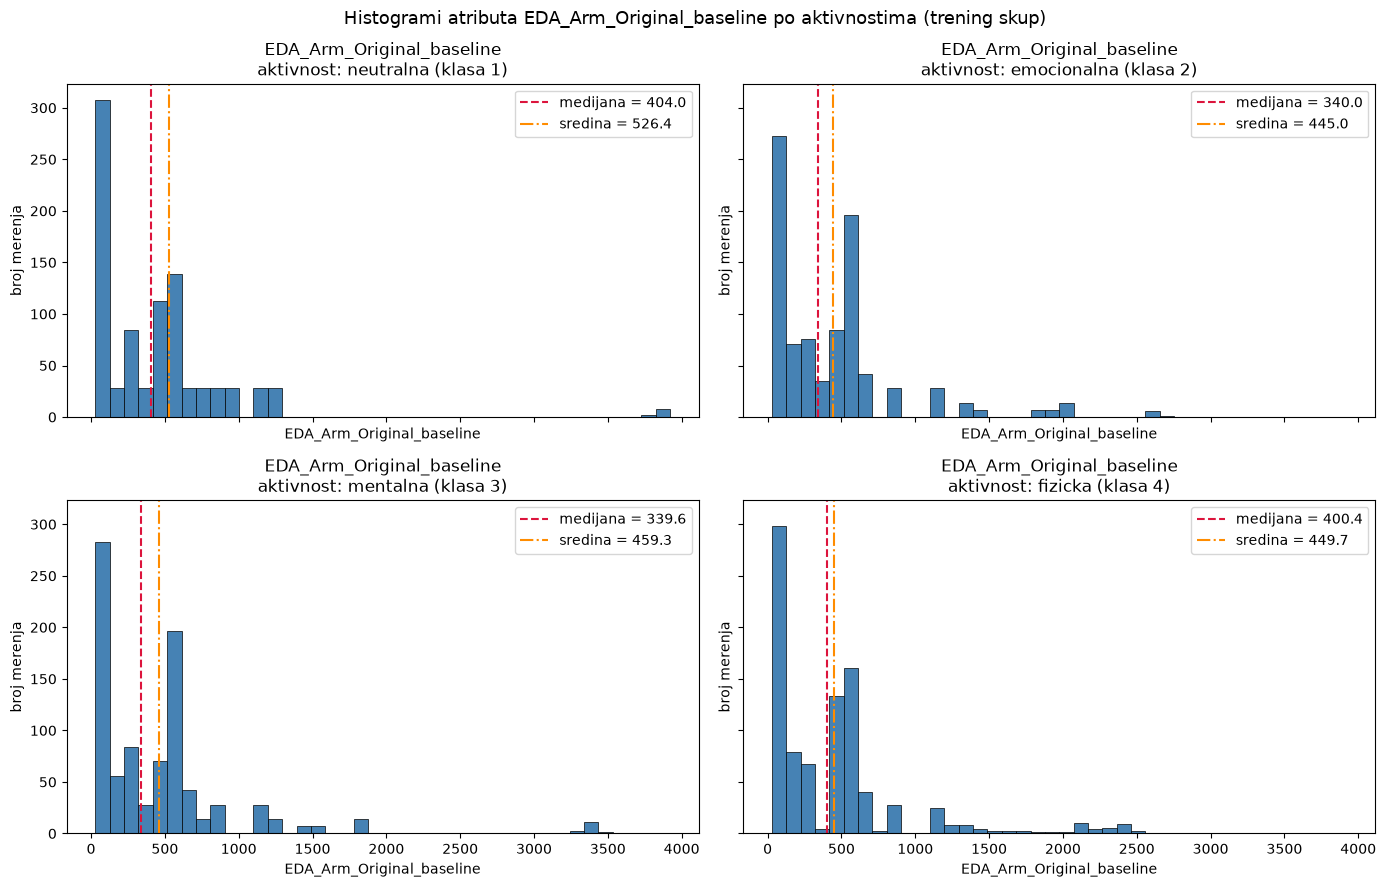

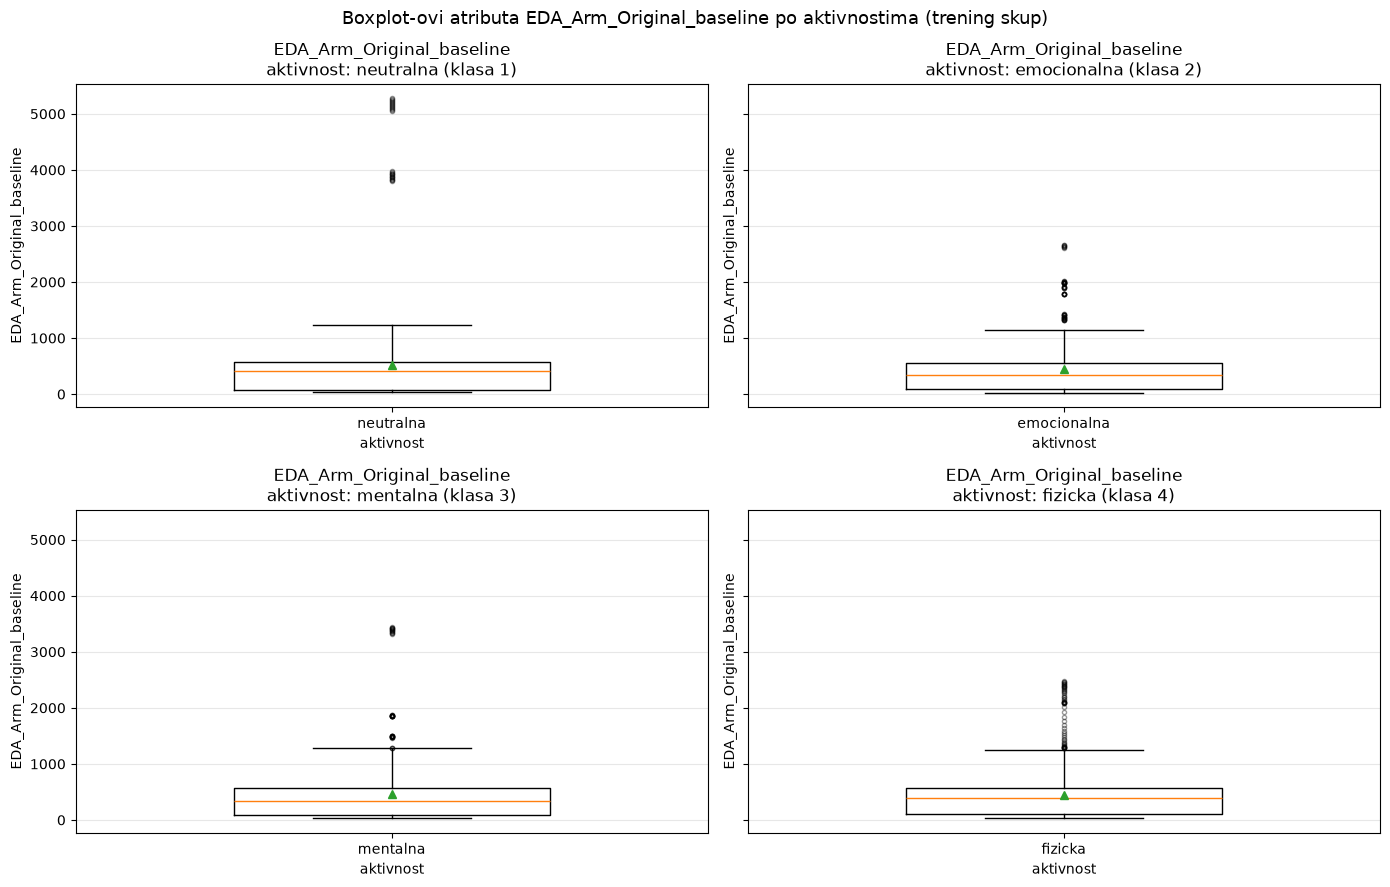

Rezime raspodele atributa EDA_Arm_Original_baseline po aktivnostima: 
             medijana  sredina     std      Q1      Q3     IQR
neutralna      403.96   526.36  796.69   77.31  570.80  493.49
emocionalna    340.05   444.97  451.95   98.75  553.87  455.11
mentalna       339.63   459.30  522.79   95.31  568.42  473.11
fizicka        400.42   449.75  473.65  104.07  563.79  459.72
Razlika najvece i najmanje medijane po klasama:  64.34
Prosecan IQR unutar klase:  470.36
Odnos razlike medijana i prosecnog IQR-a:  0.1368


In [6]:
# Analiza raspodela izabranih atributa po aktivnostima.
# Uzajamna informacija nam kaze samo koliko je atribut informativan (jedan broj), ali ne i kako tacno razdvaja klase - da li jedna aktivnost ima
# pomerenu sredinu, da li se razlikuju po rasipanju, da li postoji preklapanje raspodela. Zato za atribut sa najvecom uzajamnom informacijom
# medju izabranim atributima crtamo histogram i boxplot posebno za svaku od 4 aktivnosti, kako bismo videli da li se raspodele stvarno razdvajaju.
# Sve crtamo iskljucivo nad trening skupom, iz istog razloga kao i kod redukcije dimenzionalnosti - test skup ne smemo ni da gledamo.

import matplotlib.pyplot as plt

ACTIVITY_NAMES = {1: "neutralna", 2: "emocionalna", 3: "mentalna", 4: "fizicka"}

# atribut sa najvecom uzajamnom informacijom medju izabranim atributima
top_feature = mi_scores.loc[selected_features].idxmax()
feature_values = X_train_reduced[top_feature]
activities = sorted(ACTIVITY_NAMES)

print("Atribut sa najvecom uzajamnom informacijom medju izabranim atributima: ", top_feature)
print("Vrednost uzajamne informacije: ", round(float(mi_scores[top_feature]), 4))

# --- Histogrami po aktivnostima ---
# Svi podgrafici moraju da dele iste granice binova i istu skalu na obe ose, inace bi svaki podgrafik imao svoju skalu
# pa bi raspodele izgledale slicnije (ili razlicitije) nego sto stvarno jesu.
# Atribut ima izrazito dug desni rep, pa histogram crtamo na opsegu [0.5, 99.5] percentila - u suprotnom bi nekoliko ekstremnih
# vrednosti razvuklo x-osu i sve ostale vrednosti bi upale u prvih par binova.
lower_bound = feature_values.quantile(0.005)
upper_bound = feature_values.quantile(0.995)
bins = np.linspace(lower_bound, upper_bound, 41)
outside_range = int(((feature_values < lower_bound) | (feature_values > upper_bound)).sum())
print(f"Broj merenja van prikazanog opsega histograma [{lower_bound:.2f}, {upper_bound:.2f}]: {outside_range} od {len(feature_values)}")

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
for ax, activity in zip(axes.ravel(), activities):
    values = feature_values[y_train == activity]
    ax.hist(values, bins=bins, color="steelblue", edgecolor="black", linewidth=0.5)
    ax.axvline(values.median(), color="crimson", linestyle="--", linewidth=1.5, label=f"medijana = {values.median():.1f}")
    ax.axvline(values.mean(), color="darkorange", linestyle="-.", linewidth=1.5, label=f"sredina = {values.mean():.1f}")
    ax.set_title(f"{top_feature}\naktivnost: {ACTIVITY_NAMES[activity]} (klasa {activity})")
    ax.set_xlabel(top_feature)
    ax.set_ylabel("broj merenja")
    ax.legend()
fig.suptitle(f"Histogrami atributa {top_feature} po aktivnostima (trening skup)", fontsize=13)
fig.tight_layout()
plt.show()

# --- Boxplot-ovi po aktivnostima ---
# Boxplot pokazuje ono sto se sa histograma tesko procita: tacan polozaj medijane, sirinu interkvartilnog raspona (IQR, "kutija" u kojoj je srednjih 50% merenja)
# i koliko ima ekstremnih vrednosti. Takodje delimo y-osu izmedju podgrafika kako bi kutije bile uporedive.
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
for ax, activity in zip(axes.ravel(), activities):
    values = feature_values[y_train == activity]
    ax.boxplot(
        values,
        widths=0.5,
        showmeans=True,
        tick_labels=[ACTIVITY_NAMES[activity]],
        flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
    )
    ax.set_title(f"{top_feature}\naktivnost: {ACTIVITY_NAMES[activity]} (klasa {activity})")
    ax.set_ylabel(top_feature)
    ax.set_xlabel("aktivnost")
    ax.grid(axis="y", alpha=0.3)
fig.suptitle(f"Boxplot-ovi atributa {top_feature} po aktivnostima (trening skup)", fontsize=13)
fig.tight_layout()
plt.show()

# --- Brojcani rezime koji prati grafike ---
# medijana i IQR su otporni na ekstremne vrednosti, pa su ovde informativniji od sredine i standardne devijacije
summary = pd.DataFrame({
    "medijana": feature_values.groupby(y_train).median(),
    "sredina": feature_values.groupby(y_train).mean(),
    "std": feature_values.groupby(y_train).std(),
    "Q1": feature_values.groupby(y_train).quantile(0.25),
    "Q3": feature_values.groupby(y_train).quantile(0.75),
})
summary["IQR"] = summary["Q3"] - summary["Q1"]
summary.index = [ACTIVITY_NAMES[activity] for activity in summary.index]

print("Rezime raspodele atributa", top_feature, "po aktivnostima: ")
print(summary.round(2))

# koliko se medijane klasa uopste razlikuju u odnosu na rasipanje unutar klase - ako je ovaj odnos mali, klase se preklapaju
median_spread = summary["medijana"].max() - summary["medijana"].min()
print("Razlika najvece i najmanje medijane po klasama: ", round(float(median_spread), 2))
print("Prosecan IQR unutar klase: ", round(float(summary["IQR"].mean()), 2))
print("Odnos razlike medijana i prosecnog IQR-a: ", round(float(median_spread / summary["IQR"].mean()), 4))


Udeo varijanse koji dolazi od razlike izmedju ispitanika za EDA_Arm_Original_baseline :  0.8322


Poredjenje po svim izabranim atributima (sortirano po udelu varijanse izmedju ispitanika): 
                           udeo_var_izmedju_ispitanika  MI_sirovo  \
ECG_amplitude_RR_baseline                        0.963      0.835   
ECG_PSD_baseline                                 0.952      0.606   
ECG_HR_min_div_baseline                          0.936      0.668   
EDA_Arm_Original_baseline                        0.832      1.008   
EDA_Hand_Filt2_max                               0.736      0.693   
IT_BRV_baseline                                  0.525      0.661   
EDA_Hand_processed_max                           0.331      0.776   
ECG_amplitude_RR_min                             0.291      0.838   
ECG_amplitude_RR_max                             0.284      0.768   
IT_Original_min                                  0.257      0.716   
IT_BR_mean                                       0.211      0.681   
EDA_Arm_processed_min                            0.170      0.724   
IT_RF_min  

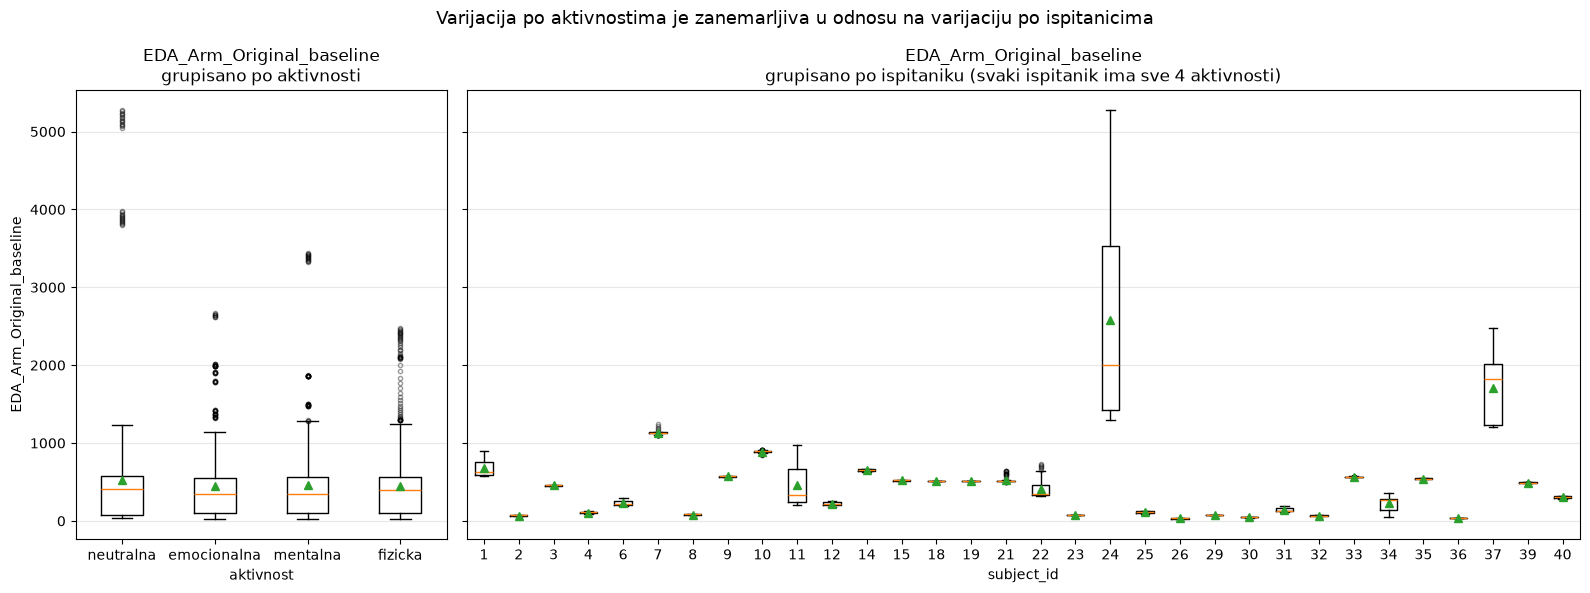

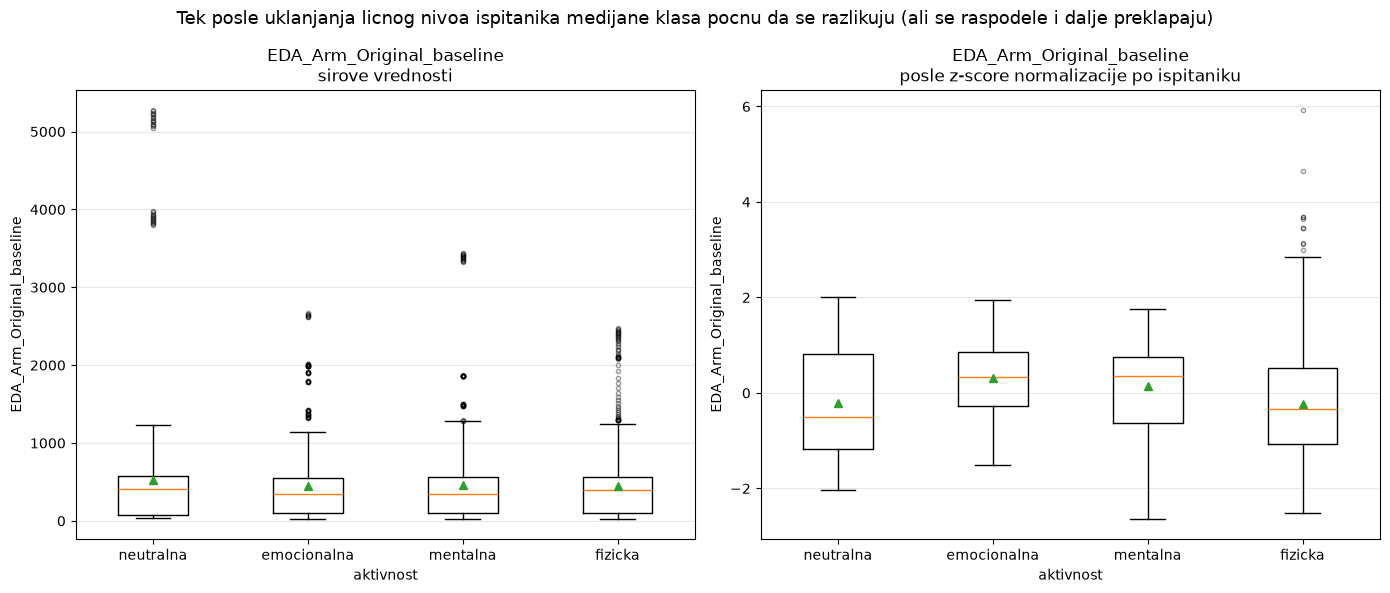

Medijane po aktivnostima posle normalizacije po ispitaniku: 
target
neutralna     -0.499
emocionalna    0.332
mentalna       0.345
fizicka       -0.347
Name: EDA_Arm_Original_baseline, dtype: float64
Redosledi blokova aktivnosti medju ispitanicima iz trening skupa: 
  redosled neutralna -> mentalna -> emocionalna -> mentalna -> emocionalna -> fizicka
    broj ispitanika sa ovim redosledom: 32 od 32
MI izmedju rednog broja merenja unutar ispitanika i aktivnosti:  1.3867
Maksimalna moguca MI za 4 balansirane klase (ln 4):  1.3863


In [7]:
# Zakljucak iz prethodnog koraka: atribut sa najvecom uzajamnom informacijom (EDA_Arm_Original_baseline, MI = 1.0084) ima gotovo identicne raspodele
# za sve 4 aktivnosti - medijane se razlikuju za 64 jedinice, dok je prosecan IQR unutar klase 470, pa se kutije skoro potpuno preklapaju.
# Deluje kontradiktorno: kako atribut moze da bude najinformativniji po MI, a da vizuelno uopste ne razdvaja klase?
# Hipoteza: MI je ovde naduvan jer varijansa atributa ne dolazi od aktivnosti nego od samog ispitanika (svaki covek ima svoj nivo provodljivosti koze).
# mutual_info_classif koristi ocenu zasnovanu na k najblizih suseda, pa su susedi jednog merenja gotovo uvek merenja istog ispitanika - lokalno, unutar
# jednog ispitanika, aktivnosti se stvarno razlikuju i ocena to pokupi, ali ta razlika nestane kada se svi ispitanici pomesaju u jednu raspodelu.
# U nastavku to proveravamo na tri nacina: dekompozicijom varijanse, poredjenjem MI pre i posle normalizacije po ispitaniku, i graficki.

from itertools import groupby

# --- Dokaz 1: koliki deo varijanse atributa dolazi od razlike izmedju ispitanika, a koliki od merenja unutar istog ispitanika ---
# ukupnu varijansu delimo na deo izmedju ispitanika (varijansa prosekâ po ispitaniku) i ostatak (varijacija unutar ispitanika).
# Ako je udeo izmedju ispitanika blizu 1, atribut prakticno meri "ko je ispitanik", a ne "koju aktivnost radi".
between_subject_share = X_train_reduced[top_feature].groupby(groups_train).mean().var() / X_train_reduced[top_feature].var()
print("Udeo varijanse koji dolazi od razlike izmedju ispitanika za", top_feature, ": ", round(float(between_subject_share), 4))

# --- Dokaz 2: uzajamna informacija pre i posle normalizacije po ispitaniku ---
# Svakom ispitaniku posebno oduzmemo njegov prosek i podelimo njegovom standardnom devijacijom (z-score unutar ispitanika).
# Time uklanjamo licni nivo signala, a ostaje samo relativna promena u odnosu na sopstveni prosek - tacno ono sto bi trebalo da nosi informaciju o aktivnosti.
# Ako MI posle toga naglo padne, znaci da je pre normalizacije MI merila identitet ispitanika, a ne aktivnost.
X_train_normalized = X_train_reduced.groupby(groups_train).transform(lambda values: (values - values.mean()) / values.std())

# MI racunamo nad oba skupa u istom redosledu kolona i sa istim seed-om, kako bi poredjenje bilo posteno
# (mutual_info_classif dodaje mali slucajni sum na atribute, pa se vrednosti mogu neznatno razlikovati od onih iz koraka 2)
mi_raw = pd.Series(mutual_info_classif(X_train_reduced, y_train, random_state=RANDOM_STATE), index=X_train_reduced.columns)
mi_normalized = pd.Series(mutual_info_classif(X_train_normalized, y_train, random_state=RANDOM_STATE), index=X_train_normalized.columns)

variance_summary = pd.DataFrame({
    "udeo_var_izmedju_ispitanika": X_train_reduced.groupby(groups_train).mean().var() / X_train_reduced.var(),
    "MI_sirovo": mi_raw,
    "MI_posle_normalizacije": mi_normalized,
})
variance_summary["odnos_MI"] = variance_summary["MI_posle_normalizacije"] / variance_summary["MI_sirovo"]
variance_summary = variance_summary.sort_values("udeo_var_izmedju_ispitanika", ascending=False)

print("Poredjenje po svim izabranim atributima (sortirano po udelu varijanse izmedju ispitanika): ")
print(variance_summary.round(3))

# Veza nije glatka nego pragovska - MI pada tek kod atributa kod kojih varijansa izmedju ispitanika potpuno dominira,
# dok kod ostalih atributa normalizacija ne smeta, a ponegde cak i pomogne (uklanja se sum vezan za ispitanika).
dominated_by_subject = variance_summary["udeo_var_izmedju_ispitanika"] > 0.8
print("Atributi kod kojih varijansa izmedju ispitanika dominira (udeo > 0.8): ", int(dominated_by_subject.sum()))
print("  prosecan odnos MI posle/pre normalizacije: ", round(float(variance_summary.loc[dominated_by_subject, "odnos_MI"].mean()), 3))
print("Ostali atributi: ", int((~dominated_by_subject).sum()))
print("  prosecan odnos MI posle/pre normalizacije: ", round(float(variance_summary.loc[~dominated_by_subject, "odnos_MI"].mean()), 3))

# --- Dokaz 3 (grafik): ista skala, levo grupisano po aktivnosti, desno po ispitaniku ---
# Ovo je najdirektniji prikaz - ako je hipoteza tacna, kutije po aktivnostima su skoro identicne, a kutije po ispitanicima se drasticno razlikuju.
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True, width_ratios=[1, 3])

axes[0].boxplot(
    [X_train_reduced[top_feature][y_train == activity] for activity in activities],
    tick_labels=[ACTIVITY_NAMES[activity] for activity in activities],
    showmeans=True,
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
)
axes[0].set_title(f"{top_feature}\ngrupisano po aktivnosti")
axes[0].set_xlabel("aktivnost")
axes[0].set_ylabel(top_feature)
axes[0].grid(axis="y", alpha=0.3)

train_subjects = sorted(groups_train.unique())
axes[1].boxplot(
    [X_train_reduced[top_feature][groups_train == subject] for subject in train_subjects],
    tick_labels=[str(subject) for subject in train_subjects],
    showmeans=True,
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
)
axes[1].set_title(f"{top_feature}\ngrupisano po ispitaniku (svaki ispitanik ima sve 4 aktivnosti)")
axes[1].set_xlabel("subject_id")
axes[1].grid(axis="y", alpha=0.3)

fig.suptitle("Varijacija po aktivnostima je zanemarljiva u odnosu na varijaciju po ispitanicima", fontsize=13)
fig.tight_layout()
plt.show()

# --- Dokaz 4 (grafik): iste kutije po aktivnostima, pre i posle normalizacije po ispitaniku ---
# Levo su sirove vrednosti (kutije se preklapaju), desno vrednosti posle uklanjanja licnog nivoa svakog ispitanika.
# Posle normalizacije se pojavljuje pomeraj medijana izmedju aktivnosti koji je u sirovim podacima bio potpuno zamaskiran,
# ali treba biti realan - raspodele se i dalje znatno preklapaju, pa je i taj ostatak signala slab (MI padne sa 1.008 na 0.297).
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (data_frame, subtitle) in zip(
    axes,
    [(X_train_reduced, "sirove vrednosti"), (X_train_normalized, "posle z-score normalizacije po ispitaniku")],
):
    ax.boxplot(
        [data_frame[top_feature][y_train == activity] for activity in activities],
        tick_labels=[ACTIVITY_NAMES[activity] for activity in activities],
        showmeans=True,
        flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
    )
    ax.set_title(f"{top_feature}\n{subtitle}")
    ax.set_xlabel("aktivnost")
    ax.set_ylabel(top_feature)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Tek posle uklanjanja licnog nivoa ispitanika medijane klasa pocnu da se razlikuju (ali se raspodele i dalje preklapaju)", fontsize=13)
fig.tight_layout()
plt.show()

print("Medijane po aktivnostima posle normalizacije po ispitaniku: ")
print(X_train_normalized[top_feature].groupby(y_train).median().rename(index=ACTIVITY_NAMES).round(3))